# Individual Task 1 — Forecasting Australian Unemployment Rate
### Job role: Westpac Group — Data Scientist, AI & Analytics

**Professional question:** Does adding RBA H3 monthly economic activity data improve the prediction of next month’s unemployment rate compared with using only RBA H5 labour market data?

**Datasets:** RBA H3 mmonthly Activity Indicator (h03hist.xslx), RBA H5 Labour Force (h05hist.xlsx). 
Both datasets have been taken from the RBA website. 

#### Import Libraries

In [62]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [63]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

#### 1. Load the data

In [64]:
h3_raw = pd.read_excel("h03hist.xlsx", sheet_name="Data", header=None)
h5_raw = pd.read_excel("h05hist.xlsx", sheet_name="Data", header=None)

In [65]:
print(h3_raw.shape)
print(h5_raw.shape)

(753, 6)
(595, 19)


In [66]:
h3_raw.head(20)

,0,1,2,3,4,5
0,H3 MONTHLY ACTIVITY INDICATORS,NaN,NaN,NaN,NaN,NaN
1,Title,Private dwelling approvals,Private dwelling approvals trend,Private non-residential building approvals,Consumer sentiment,Business conditions
2,Description,Private dwelling approvals,Private dwelling approvals; Trend,Private non-residential building approvals; Cu...,Westpac-Melbourne Institute consumer sentiment...,NAB business conditions index deviation from a...
3,Frequency,Monthly,Monthly,Monthly,Monthly,Monthly
4,Type,Seasonally adjusted,Trend,Original,Seasonally adjusted,Seasonally adjusted
5,Units,'000,'000,$ million,Index,Percentage points
6,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN
8,Source,ABS,ABS,ABS,MI,NAB
9,Publication date,31-Jul-2026,31-Jul-2026,31-Jul-2026,16-Jul-2026,16-Jul-2026


In [67]:
h5_raw.head(20)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,H5 LABOUR FORCE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Title,Labour force,Participation rate,Part-time employment,Full-time employment,Employment,Year-ended employment growth,Year-ended employment trend growth,Employment to population ratio,Unemployment,Unemployment rate,Unemployment rate trend,Hours worked,Hours worked trend,Year-ended hours worked trend growth,Average hours worked trend,Job vacancies,Private sector job vacancies,Vacancies to labour force ratio
2,Description,Labour force persons,Labour force participation rate,Part-time employed persons,Full-time employed persons,Employed persons,Employed persons; Year-ended change (in per cent),Employed persons; Trend; Year-ended change (in...,Employed persons as percentage of working age ...,Unemployed persons,Unemployed persons as percentage of labour force,Unemployed persons as percentage of labour for...,Total hours worked per month,Total hours worked per month; Trend,Total hours worked per month; Trend; Year-ende...,Average hours worked per week,Number of job vacancies,Number of job vacancies in private sector,Job vacancies as percentage of labour force
3,Frequency,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Quarterly,Quarterly,Quarterly
4,Type,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Trend,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Trend,Seasonally adjusted,Trend,Trend,Trend,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted
5,Units,'000,Per cent,'000,'000,'000,Per cent,Per cent,Per cent,'000,Per cent,Per cent,'000,'000,Per cent,Hours,'000,'000,Per cent
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Source,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS
9,Publication date,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,26-Jun-2026,26-Jun-2026,26-Jun-2026


**Observation:** It is observed that in both dataset the first 11 rows contains metadata about the data set. So this can be stored separately in a dictionary.

In [68]:
h3_dict = h3_raw.iloc[1:11, :].copy()
h3_dict.index = ["Title","Description","Frequency","Type","Units",
                  "Nan1","Nan2","Source","Publication date","Series ID"]

h3_dict = h3_dict.drop(index=["Nan1","Nan2"])
h3_dict.columns = ["date_col"] + [f"var_{i}" for i in range(1, h3_dict.shape[1])]

In [69]:
h5_dict = h5_raw.iloc[1:11, :].copy()
h5_dict.index = ["Title","Description","Frequency","Type","Units",
                  "Nan1","Nan2","Source","Publication date","Series ID"]

h5_dict = h5_dict.drop(index=["Nan1","Nan2"])
h5_dict.columns = ["date_col"] + [f"var_{i}" for i in range(1, h5_dict.shape[1])]

In [70]:
h3_dict


,date_col,var_1,var_2,var_3,var_4,var_5
Title,Title,Private dwelling approvals,Private dwelling approvals trend,Private non-residential building approvals,Consumer sentiment,Business conditions
Description,Description,Private dwelling approvals,Private dwelling approvals; Trend,Private non-residential building approvals; Cu...,Westpac-Melbourne Institute consumer sentiment...,NAB business conditions index deviation from a...
Frequency,Frequency,Monthly,Monthly,Monthly,Monthly,Monthly
Type,Type,Seasonally adjusted,Trend,Original,Seasonally adjusted,Seasonally adjusted
Units,Units,'000,'000,$ million,Index,Percentage points
Source,Source,ABS,ABS,ABS,MI,NAB
Publication date,Publication date,31-Jul-2026,31-Jul-2026,31-Jul-2026,16-Jul-2026,16-Jul-2026
Series ID,Series ID,GISPSDA,GISDWPRITR,GISPSNBA,GICWMICS,GICNBC


In [71]:
h5_dict

,date_col,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,var_10,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18
Title,Title,Labour force,Participation rate,Part-time employment,Full-time employment,Employment,Year-ended employment growth,Year-ended employment trend growth,Employment to population ratio,Unemployment,Unemployment rate,Unemployment rate trend,Hours worked,Hours worked trend,Year-ended hours worked trend growth,Average hours worked trend,Job vacancies,Private sector job vacancies,Vacancies to labour force ratio
Description,Description,Labour force persons,Labour force participation rate,Part-time employed persons,Full-time employed persons,Employed persons,Employed persons; Year-ended change (in per cent),Employed persons; Trend; Year-ended change (in...,Employed persons as percentage of working age ...,Unemployed persons,Unemployed persons as percentage of labour force,Unemployed persons as percentage of labour for...,Total hours worked per month,Total hours worked per month; Trend,Total hours worked per month; Trend; Year-ende...,Average hours worked per week,Number of job vacancies,Number of job vacancies in private sector,Job vacancies as percentage of labour force
Frequency,Frequency,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Monthly,Quarterly,Quarterly,Quarterly
Type,Type,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Trend,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted,Trend,Seasonally adjusted,Trend,Trend,Trend,Seasonally adjusted,Seasonally adjusted,Seasonally adjusted
Units,Units,'000,Per cent,'000,'000,'000,Per cent,Per cent,Per cent,'000,Per cent,Per cent,'000,'000,Per cent,Hours,'000,'000,Per cent
Source,Source,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS,ABS
Publication date,Publication date,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,24-Jul-2026,26-Jun-2026,26-Jun-2026,26-Jun-2026
Series ID,Series ID,GLFSLFSA,GLFSPRSA,GLFSEPPSA,GLFSEPFSA,GLFSEPTSA,GLFSEPTSYP,GLFSEPTTYP,GLFSEPTPOP,GLFSUPSA,GLFSURSA,GLFSURTR,GLFMHW,GLFMHWTR,GLFMHWTRYP,GLFMHWAV,GLFOSVT,GLFOSVPS,GLFOSVTLF


#### 2. Dataset Cleaning

The first step is to extract title and remove meta data in the cleaned version of the data.


**H3 data cleaning**

In [72]:
h3_titles = h3_raw.iloc[1, 1:].astype(str).str.strip().tolist()

h3_clean = h3_raw.iloc[11:].copy()
h3_clean.columns = ["date"] + h3_titles

In [73]:
h3_clean.head(5)

,date,Private dwelling approvals,Private dwelling approvals trend,Private non-residential building approvals,Consumer sentiment,Business conditions
11,1965-01-31 00:00:00,8.777,NaN,NaN,NaN,NaN
12,1965-02-28 00:00:00,9.059,NaN,NaN,NaN,NaN
13,1965-03-31 00:00:00,8.745,NaN,NaN,NaN,NaN
14,1965-04-30 00:00:00,8.893,NaN,NaN,NaN,NaN
15,1965-05-31 00:00:00,8.387,NaN,NaN,NaN,NaN


In [74]:
h3_clean.dtypes

date                                          object
Private dwelling approvals                    object
Private dwelling approvals trend              object
Private non-residential building approvals    object
Consumer sentiment                            object
Business conditions                           object
dtype: object

In the dataset the Date column is in the object data type. The next step is to convert the data type of the date column to Datetime. Also the numeric columns in the object datatype. It is necessary for forcsting to convert them to numeric datatype

In [75]:
h3_clean["date"] = pd.to_datetime(h3_clean["date"], errors="coerce")
h3_clean = h3_clean.dropna(subset=["date"])

h3_indicator_cols = h3_clean.columns.drop("date")
h3_clean[h3_indicator_cols] = h3_clean[h3_indicator_cols].apply(pd.to_numeric, errors="coerce")

h3_indicator_cols = h3_clean.columns.drop("date")
h3_clean[h3_indicator_cols] = h3_clean[h3_indicator_cols].apply(pd.to_numeric, errors="coerce")

h3_clean = h3_clean.dropna(how="all", subset=h3_indicator_cols)
h3_clean = h3_clean.sort_values("date").reset_index(drop=True)

In [76]:
print(f'CLeaned H3 shape: {h3_clean.shape}')
print(h3_clean.dtypes)
print(f"H3 date range: {h3_clean["date"].min(), "to", h3_clean["date"].max()}")
print(f"H3 duplicate dates: {h3_clean["date"].duplicated().sum()}")

CLeaned H3 shape: (739, 6)
date                                          datetime64[ns]
Private dwelling approvals                           float64
Private dwelling approvals trend                     float64
Private non-residential building approvals           float64
Consumer sentiment                                   float64
Business conditions                                  float64
dtype: object
H3 date range: (Timestamp('1965-01-31 00:00:00'), 'to', Timestamp('2026-07-31 00:00:00'))
H3 duplicate dates: 0


**H5 Data cleaning**

In [77]:
h5_titles = h5_raw.iloc[1, 1:].astype(str).str.strip().tolist()

h5_clean = h5_raw.iloc[11:].copy()
h5_clean.columns = ["date"] + h5_titles

In [78]:
h5_clean.head(5)

,date,Labour force,Participation rate,Part-time employment,Full-time employment,Employment,Year-ended employment growth,Year-ended employment trend growth,Employment to population ratio,Unemployment,Unemployment rate,Unemployment rate trend,Hours worked,Hours worked trend,Year-ended hours worked trend growth,Average hours worked trend,Job vacancies,Private sector job vacancies,Vacancies to labour force ratio
11,1978-02-28 00:00:00,6424.298026,61.246029,918.108242,5079.313233,5997.421476,NaN,NaN,57.176402,426.87655,6.644719,6.30389,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,1978-03-31 00:00:00,6406.68578,60.965884,907.818205,5095.05709,6002.875296,NaN,NaN,57.123232,403.810485,6.302954,6.292648,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,1978-04-30 00:00:00,6433.919613,61.166687,911.214813,5119.460828,6030.675641,NaN,NaN,57.333083,403.243972,6.26747,6.27745,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,1978-05-31 00:00:00,6432.50135,61.083492,914.333069,5118.748679,6033.081748,NaN,NaN,57.290575,399.419601,6.209398,6.267932,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,1978-06-30 00:00:00,6439.776641,61.078898,929.683714,5104.128054,6033.811769,NaN,NaN,57.228471,405.964873,6.304021,6.264376,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [79]:
h5_clean.dtypes

date                                    object
Labour force                            object
Participation rate                      object
Part-time employment                    object
Full-time employment                    object
Employment                              object
Year-ended employment growth            object
Year-ended employment trend growth      object
Employment to population ratio          object
Unemployment                            object
Unemployment rate                       object
Unemployment rate trend                 object
Hours worked                            object
Hours worked trend                      object
Year-ended hours worked trend growth    object
Average hours worked trend              object
Job vacancies                           object
Private sector job vacancies            object
Vacancies to labour force ratio         object
dtype: object

In the dataset the Date column is in the object data type. The next step is to convert the data type of the date column to Datetime. Also the numeric columns in the object datatype. It is necessary for forcsting to convert them to numeric datatype

In [80]:

h5_clean["date"] = pd.to_datetime(h5_clean["date"], errors="coerce")
h5_clean = h5_clean.dropna(subset=["date"])
h5_indicator_cols = h5_clean.columns.drop("date")
h5_clean[h5_indicator_cols] = h5_clean[h5_indicator_cols].apply(pd.to_numeric, errors="coerce")


In [81]:
h5_clean = h5_clean.dropna(how="all", subset=h5_indicator_cols)
h5_clean = h5_clean.sort_values("date").reset_index(drop=True)


In [82]:
print(f'CLeaned H3 shape: {h5_clean.shape}')
print(h5_clean.dtypes)
print(f"H3 date range: {h5_clean["date"].min(), "to", h5_clean["date"].max()}")
print(f"H3 duplicate dates: {h5_clean["date"].duplicated().sum()}")

CLeaned H3 shape: (581, 19)
date                                    datetime64[ns]
Labour force                                   float64
Participation rate                             float64
Part-time employment                           float64
Full-time employment                           float64
Employment                                     float64
Year-ended employment growth                   float64
Year-ended employment trend growth             float64
Employment to population ratio                 float64
Unemployment                                   float64
Unemployment rate                              float64
Unemployment rate trend                        float64
Hours worked                                   float64
Hours worked trend                             float64
Year-ended hours worked trend growth           float64
Average hours worked trend                     float64
Job vacancies                                  float64
Private sector job vacancies         

#### 3 To Build a analysis-ready datasets

After analysing the dataset it is found that there are no consistent and sufficient observation before 2010 in H3 dataset. The the common period from both i.e January 2010 -  June 2026 is selected. 

In [83]:
h3_period = h3_clean[(h3_clean["date"] >= "2010-01-01") & (h3_clean["date"] <= "2026-06-30")].reset_index(drop=True)
h5_period = h5_clean[(h5_clean["date"] >= "2010-01-01") & (h5_clean["date"] <= "2026-06-30")].reset_index(drop=True)



In order to use both datasets togetherly we need to check if the dates used in both both are same or not. 

In [84]:
print(f"h3_period: {h3_period.shape, h3_period["date"].min()} to {h3_period["date"].max()}")
print(f"h5_period: {h5_period.shape, h5_period["date"].min()} to{h5_period["date"].max()}")
print(f"Dates match across datasets: {h3_period["date"].equals(h5_period["date"])}")

h3_period: ((198, 6), Timestamp('2010-01-31 00:00:00')) to 2026-06-30 00:00:00
h5_period: ((198, 19), Timestamp('2010-01-31 00:00:00')) to2026-06-30 00:00:00
Dates match across datasets: True


In [85]:
missing_h3 = h3_period.isna().sum()
missing_h5 = h5_period.isna().sum()
print(f"H3 missing values (period):\n {missing_h3}")
print(f"\nH5 missing values (period):\n {missing_h5}")

H3 missing values (period):
 date                                          0
Private dwelling approvals                    0
Private dwelling approvals trend              0
Private non-residential building approvals    0
Consumer sentiment                            0
Business conditions                           0
dtype: int64

H5 missing values (period):
 date                                      0
Labour force                              0
Participation rate                        0
Part-time employment                      0
Full-time employment                      0
Employment                                0
Year-ended employment growth              0
Year-ended employment trend growth        0
Employment to population ratio            0
Unemployment                              0
Unemployment rate                         0
Unemployment rate trend                   0
Hours worked                              0
Hours worked trend                        0
Year-ended hours worked 

The job vacancies, private sector job vacancies and vacancies to labour force ratio are labelled as Frequency = Quarterly in the metadata. So the missing values shown are not data quality error but it is structure of the dataset. But, for the one month ahead forcasting we don't need the quarterly values, so that columns can be dropped from the analysis dataset.

In [86]:
quarterly_cols = ["Job vacancies", "Private sector job vacancies", "Vacancies to labour force ratio"]
h5_quarterly = h5_period[["date"] + quarterly_cols].dropna(subset=quarterly_cols).reset_index(drop=True)
print("H5 quarterly observed values:", h5_quarterly.shape)


H5 quarterly observed values: (66, 4)


In [87]:
combined_full = pd.merge(h3_period, h5_period, on="date", how="inner", validate="one_to_one")
combined_full = combined_full.sort_values("date").reset_index(drop=True)

In [88]:
h5_monthly_only = h5_period.drop(columns=quarterly_cols)
combined_monthly = pd.merge(h3_period, h5_monthly_only, on="date", how="inner", validate="one_to_one")
combined_monthly = combined_monthly.sort_values("date").reset_index(drop=True)

In [89]:
print(f"combined_full: {combined_full.shape}")
print(f"combined_monthly: {combined_monthly.shape}")
print(f"combined_monthly missing values: {combined_monthly.isna().sum().sum()}")
print(f"Duplicate dates in combined_full: {combined_full["date"].duplicated().sum()}")

combined_full: (198, 24)
combined_monthly: (198, 21)
combined_monthly missing values: 0
Duplicate dates in combined_full: 0


In [90]:
combined_monthly.head(10)

,date,Private dwelling approvals,Private dwelling approvals trend,Private non-residential building approvals,Consumer sentiment,Business conditions,Labour force,Participation rate,Part-time employment,Full-time employment,...,Year-ended employment growth,Year-ended employment trend growth,Employment to population ratio,Unemployment,Unemployment rate,Unemployment rate trend,Hours worked,Hours worked trend,Year-ended hours worked trend growth,Average hours worked trend
0,2010-01-31,12.916,13.628,1695.589,120.124739,3.633744,11545.125776,65.390434,3297.326698,7639.817127,...,1.354923,1.105021,61.946885,607.981950,5.266135,5.439344,1.533227e+06,1.531286e+06,0.722259,32.291333
1,2010-02-28,13.424,13.744,1342.472,117.043946,4.810134,11531.800767,65.207326,3298.032798,7622.793447,...,1.072163,1.284174,61.752530,610.974522,5.298171,5.400133,1.536424e+06,1.534573e+06,1.196691,32.314679
2,2010-03-31,14.615,13.872,1585.254,117.293819,7.302762,11552.114827,65.214739,3289.671558,7636.019694,...,1.438986,1.433935,61.678413,626.423575,5.422588,5.368031,1.524978e+06,1.537848e+06,1.657666,32.351560
3,2010-04-30,14.078,13.954,1199.664,116.078752,3.903918,11573.970075,65.265892,3259.581097,7677.948169,...,1.325547,1.579493,61.676987,636.440809,5.498898,5.328719,1.537794e+06,1.541616e+06,2.110810,32.398672
4,2010-05-31,13.775,13.955,1434.161,107.963054,5.125870,11542.505235,65.016583,3244.394872,7694.470779,...,1.542491,1.733628,61.616405,603.639584,5.229710,5.282566,1.554880e+06,1.546117e+06,2.569669,32.449262
5,2010-06-30,13.680,13.899,1890.451,101.855840,2.544985,11588.971894,65.206320,3280.086516,7712.733869,...,2.209763,1.919845,61.852024,596.151509,5.144128,5.236251,1.554492e+06,1.551304e+06,3.010673,32.491394
6,2010-07-31,14.367,13.861,1491.874,113.115677,2.683844,11634.238615,65.383522,3306.123074,7712.878126,...,2.034560,2.139232,61.925935,615.237414,5.288162,5.194065,1.548261e+06,1.556308e+06,3.340995,32.504873
7,2010-08-31,13.954,13.885,1637.522,119.173022,1.328559,11647.011371,65.377918,3284.279684,7776.642419,...,2.516112,2.354424,62.088036,586.089268,5.032100,5.155946,1.563056e+06,1.560937e+06,3.524164,32.495091
8,2010-09-30,13.153,13.927,1804.899,113.224857,2.239739,11677.557573,65.471966,3273.146604,7814.193296,...,2.564234,2.515362,62.162823,590.217673,5.054290,5.125319,1.562170e+06,1.565211e+06,3.547047,32.477486
9,2010-10-31,15.238,13.891,1879.829,116.979067,-1.244760,11724.057586,65.655358,3311.537127,7792.924869,...,2.623697,2.599703,62.185589,619.595589,5.284822,5.099325,1.568686e+06,1.569394e+06,3.465165,32.468899


#### 5 Save the processed output

In [91]:
import os
os.makedirs("data/processed", exist_ok=True)
combined_monthly.to_csv("data/processed/H3_H5_combined_monthly.csv", index=False)
print("Saved the processed files to data/processed/")

Saved the processed files to data/processed/


#### 6. Exploratory data analysis

1. Tocheck the trend of the target variable that is 'Unemployment rate' over the selected timespan.

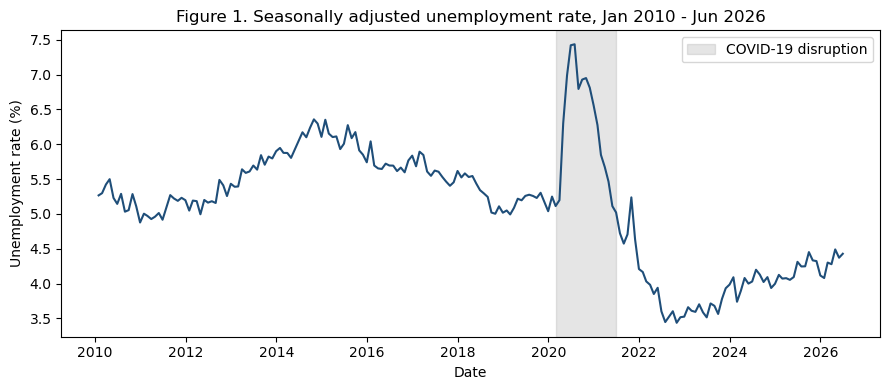

In [92]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(combined_monthly["date"], combined_monthly["Unemployment rate"], color="#1f4e79")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-30"), color="grey", alpha=0.2, label="COVID-19 disruption")
ax.set_title("Figure 1. Seasonally adjusted unemployment rate, Jan 2010 - Jun 2026")
ax.set_xlabel("Date"); ax.set_ylabel("Unemployment rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("unemployment_rate.png", dpi=150)
plt.show()

It is observed that the unemployment rate is between 5 to 6.5 percent before 2020 but the suddent spike in 2020 and 2021 indicate the COVID-19 period. This also show that along with the the variables that are changing, the sudden disaster can cause a huge increase in the unemployment rate.

**Heatmap**
A smaller group of numerical indicators from both datasets was then chosen for the correlation heatmap. These included key H3 economic activity indicators and H5 labour-market indicators that may have a meaningful relationship with unemployment. Only selected variables were displayed to keep the heatmap clear and readable. The selection was based on their economic relevance to the research question, rather than simply choosing the variables with the highest correlations. The heatmap was used to explore the strength and direction of their relationships with the unemployment rate, but these correlations do not prove causation.

In [93]:
corr_cols = ["Private dwelling approvals","Private dwelling approvals trend",
             "Private non-residential building approvals","Consumer sentiment","Business conditions",
             "Participation rate","Year-ended employment growth",
             "Employment to population ratio","Unemployment rate"]



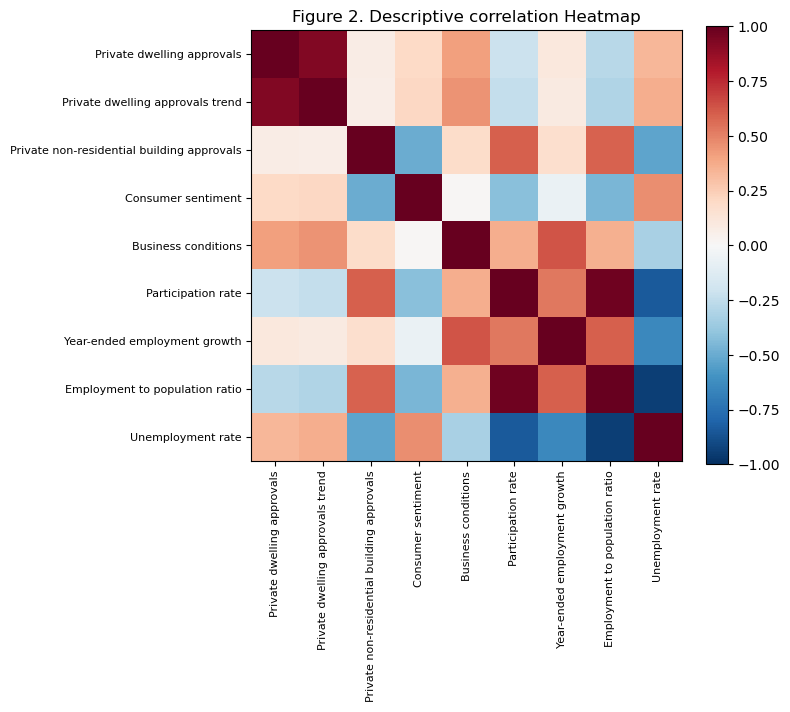

In [94]:
corr = combined_monthly[corr_cols].corr()
fig, ax = plt.subplots(figsize=(8,8))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=90, fontsize=8)
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols, fontsize=8)
ax.set_title("Figure 2. Descriptive correlation Heatmap")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig("correlation.png", dpi=150)
plt.show()

**Obervation**: The unemployment rate is very strongly correlated with the "Participation rate" and "Employment to population ratio". While it is weaky related with the H3 dataset variable. It showcases their limited standalone power in forecasting unemployment.

#### 7 Feature engineering

A small set of features was selected because the dataset contains only about 198 observations. The target is next month’s unemployment rate, while unemployment and labour-force counts were excluded to prevent data leakage.

The next month’s unemployment rate was created as the target variable. The final row was removed because the following month’s unemployment rate was unavailable.

In [95]:
h3_features = [
    "Private dwelling approvals",
    "Private dwelling approvals trend",
    "Private non-residential building approvals",
    "Consumer sentiment",
    "Business conditions",
]
h5_features = [
    "Participation rate",
    "Year-ended employment growth",
    "Employment to population ratio",
    "Unemployment rate",
]
all_features = h3_features + h5_features

In [96]:
model_df = combined_monthly[["date"] + all_features].copy()
model_df["target_next_month_unemployment_rate"] = combined_monthly["Unemployment rate"].shift(-1)
model_df = model_df.dropna(subset=["target_next_month_unemployment_rate"]).reset_index(drop=True)

In [97]:
print(f"Rows after target shift (last month dropped, no t+1 available: {model_df.shape}")

Rows after target shift (last month dropped, no t+1 available: (197, 11)


In [98]:
check = pd.DataFrame({
    "date_t": model_df["date"].head(3),
    "unemployment_rate_t": model_df["Unemployment rate"].head(3),
    "target_t+1": model_df["target_next_month_unemployment_rate"].head(3)
})
check

,date_t,unemployment_rate_t,target_t+1
0,2010-01-31,5.266135,5.298171
1,2010-02-28,5.298171,5.422588
2,2010-03-31,5.422588,5.498898


#### 8. Models and source-comparison

Two machine-learning algorithms were selected to predict the following month’s unemployment rate: Ridge Regression and Random Forest Regressor.

Ridge Regression was chosen because it provides a simple and interpretable way to understand the relationship between the economic indicators and unemployment. It also reduces the influence of strongly related variables, helping to prevent overfitting.

Random Forest Regressor was selected because it can identify more complex and nonlinear relationships in the data. Using these two different algorithms allows both simple and complex patterns to be explored. They are also different from the kNN and Decision Tree models used in my previous coursework.

As this is time-series data, the observations were kept in chronological order. The most recent 24 months were reserved as the final test set, while the earlier observations were used for training. The test set remained untouched during model development so that it could provide a fair evaluation of performance on unseen data.

Each algorithm was tested using three different groups of predictors:

**H3-only**: monthly economic activity indicators from the H3 dataset.

**H5-only**: monthly labour-market indicators from the H5 dataset.

**Combined**: both H3 economic activity and H5 labour-market indicators.

In [99]:
target = "target_next_month_unemployment_rate"
n = len(model_df)
test_size = 24
train_df = model_df.iloc[:n-test_size].reset_index(drop=True)
test_df  = model_df.iloc[n-test_size:].reset_index(drop=True)

In [100]:
print(f"Train: {train_df['date'].min().date()} to {train_df['date'].max().date()}  n={len(train_df)}")
print(f"Test:  {test_df['date'].min().date()} to {test_df['date'].max().date()}  n={len(test_df)}")

Train: 2010-01-31 to 2024-05-31  n=173
Test:  2024-06-30 to 2026-05-31  n=24


In [101]:
baseline_pred = test_df["Unemployment rate"].values
y_test = test_df[target].values

In [102]:
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_rmse = mean_squared_error(y_test, baseline_pred) ** 0.5
baseline_r2 = r2_score(y_test, baseline_pred)

In [103]:
print(f"Persistence baseline -> MAE={baseline_mae:.4f}  RMSE={baseline_rmse:.4f}  R2={baseline_r2:.4f}")

Persistence baseline -> MAE=0.0991  RMSE=0.1229  R2=0.3346


In [104]:
tscv = TimeSeriesSplit(n_splits=5)
configs = {
    "H3-only": h3_features,
    "H5-only": h5_features,
    "Combined": h3_features + h5_features,
}

results = []

In [105]:
for cfg_name, feats in configs.items():
    Xtr, ytr = train_df[feats], train_df[target]
    Xte, yte = test_df[feats], test_df[target]

    ridge_pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])
    ridge_grid = {"ridge__alpha": [0.1, 1.0, 10.0, 50.0]}
    ridge_cv = GridSearchCV(ridge_pipe, ridge_grid, cv=tscv, scoring="neg_mean_absolute_error")
    ridge_cv.fit(Xtr, ytr)
    ridge_pred = ridge_cv.predict(Xte)

    rf_grid = {"n_estimators": [200, 400], "max_depth": [3, 5, None]}
    rf_cv = GridSearchCV(RandomForestRegressor(random_state=RANDOM_SEED), rf_grid, cv=tscv, scoring="neg_mean_absolute_error")
    rf_cv.fit(Xtr, ytr)
    rf_pred = rf_cv.predict(Xte)

    for model_name, pred, best_params in [
        ("Ridge", ridge_pred, ridge_cv.best_params_),
        ("Random Forest", rf_pred, rf_cv.best_params_),
    ]:
        mae = mean_absolute_error(yte, pred)
        rmse = mean_squared_error(yte, pred) ** 0.5
        r2 = r2_score(yte, pred)
        pct_improve = (baseline_mae - mae) / baseline_mae * 100
        results.append({
            "Source config": cfg_name, "Model": model_name,
            "MAE": round(mae,4), "RMSE": round(rmse,4), "R2": round(r2,4),
            "% improvement vs baseline MAE": round(pct_improve,2),
            "Best params": str(best_params)
        })

results_df = pd.DataFrame(results)
results_df

,Source config,Model,MAE,RMSE,R2,% improvement vs baseline MAE,Best params
0,H3-only,Ridge,0.6488,0.6891,-19.9133,-554.54,{'ridge__alpha': 0.1}
1,H3-only,Random Forest,0.9183,1.0217,-44.9655,-826.47,"{'max_depth': 3, 'n_estimators': 400}"
2,H5-only,Ridge,0.1269,0.1583,-0.1037,-28.03,{'ridge__alpha': 0.1}
3,H5-only,Random Forest,0.2023,0.2412,-1.5625,-104.11,"{'max_depth': None, 'n_estimators': 400}"
4,Combined,Ridge,0.1083,0.1311,0.2431,-9.31,{'ridge__alpha': 1.0}
5,Combined,Random Forest,0.1739,0.2164,-1.0617,-75.42,"{'max_depth': 5, 'n_estimators': 400}"


In [106]:
baseline_row = pd.DataFrame([{
    "Source config": "Persistence baseline", "Model": "-",
    "MAE": round(baseline_mae,4), "RMSE": round(baseline_rmse,4), "R2": round(baseline_r2,4),
    "% improvement vs baseline MAE": 0.0, "Best params": "-"
}])
full_table = pd.concat([baseline_row, results_df], ignore_index=True)
full_table.to_csv("data/processed/test_results_with_baseline.csv", index=False)
print(full_table.to_string(index=False))

       Source config         Model    MAE   RMSE       R2  % improvement vs baseline MAE                              Best params
Persistence baseline             - 0.0991 0.1229   0.3346                           0.00                                        -
             H3-only         Ridge 0.6488 0.6891 -19.9133                        -554.54                    {'ridge__alpha': 0.1}
             H3-only Random Forest 0.9183 1.0217 -44.9655                        -826.47    {'max_depth': 3, 'n_estimators': 400}
             H5-only         Ridge 0.1269 0.1583  -0.1037                         -28.03                    {'ridge__alpha': 0.1}
             H5-only Random Forest 0.2023 0.2412  -1.5625                        -104.11 {'max_depth': None, 'n_estimators': 400}
            Combined         Ridge 0.1083 0.1311   0.2431                          -9.31                    {'ridge__alpha': 1.0}
            Combined Random Forest 0.1739 0.2164  -1.0617                         -75.42  

##### None of the six machine-learning models performed better than the persistence baseline on the final 24-month test set. Combined Ridge Regression was the best machine-learning model, with an MAE of 0.108, but its average error was still approximately 9.3% higher than the baseline MAE of 0.0991. This means that simply predicting no change in next month’s unemployment rate was more accurate during the test period.

##### This is still a useful result because unemployment usually changes gradually, making the current month’s rate a strong predictor of the following month. Although combining H3 and H5 indicators produced the best machine-learning result, it did not provide enough additional information to beat the baseline.

##### For Westpac, this shows that a more complex model is not always the better choice. Based on these results, the persistence baseline would be preferred because it is simpler, easier to explain and more accurate. Future work could test additional leading indicators and longer time lags to improve forecasting.

#### 9. Interpretability — actual-vs-predicted and feature importance

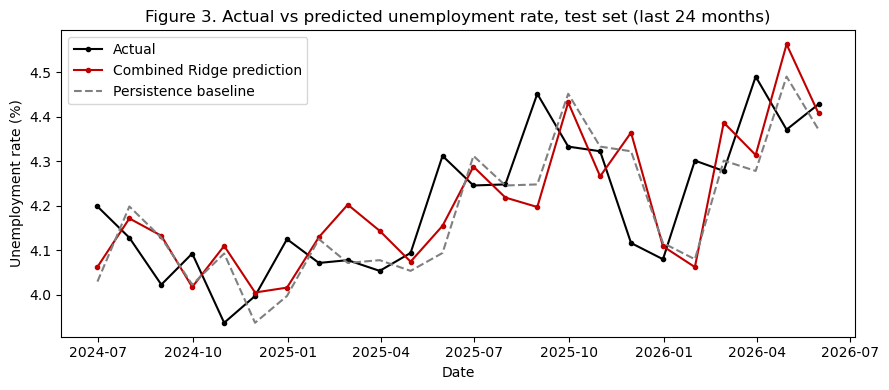

In [107]:
best_feats = h3_features + h5_features
Xtr, ytr = train_df[best_feats], train_df[target]
Xte, yte = test_df[best_feats], test_df[target]

ridge_pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])
ridge_cv = GridSearchCV(ridge_pipe, {"ridge__alpha":[0.1,1,10,50]}, cv=tscv, scoring="neg_mean_absolute_error")
ridge_cv.fit(Xtr, ytr)
ridge_pred_full = ridge_cv.predict(Xte)

fig, ax = plt.subplots(figsize=(9,4))
ax.plot(test_df["date"], yte, label="Actual", color="black", marker="o", markersize=3)
ax.plot(test_df["date"], ridge_pred_full, label="Combined Ridge prediction", color="#c00000", marker="o", markersize=3)
ax.plot(test_df["date"], test_df["Unemployment rate"], label="Persistence baseline", color="grey", linestyle="--")
ax.set_title("Figure 3. Actual vs predicted unemployment rate, test set (last 24 months)")
ax.set_xlabel("Date"); ax.set_ylabel("Unemployment rate (%)")
ax.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150)
plt.show()

##### 10. Comparing the Two Data Sources

The Combined Ridge model achieved an MAE of 0.108, while the H5-only model recorded an MAE of 0.127. This means that adding the H3 economic activity indicators reduced the prediction error compared with using the H5 labour-market data alone. Therefore, H3 appears to provide some additional information when combined with H5.

However, neither model performed better than the persistence baseline, which achieved a lower MAE of 0.099. H3 also performed poorly when used by itself, suggesting that its indicators were not strong enough to accurately predict next month’s unemployment rate on their own.

Overall, the two datasets can be viewed as partially complementary because combining them produced a better result than using H5 alone. However, the practical benefit was limited because the Combined model still could not beat the simple persistence baseline. This means that H3 added some useful information, but not enough to produce a more accurate forecast than simply assuming that next month’s unemployment rate would remain unchanged.

#### 11. Limitations

This analysis has several limitations that should be considered when interpreting the results.

- After creating the one-month-ahead target, only 197 monthly observations were available, with the latest 24 months reserved for testing. This relatively small sample limits how confidently the results can be generalised.
- The COVID-19 period was retained because it represents a genuine economic event rather than a simple data error. However, it created a major structural change that may have affected the relationships learned by the models.
- Quarterly job-vacancy indicators were excluded because they could not be directly aligned with the monthly forecasting framework. This was a modelling decision rather than a problem with the data.
- Only a small set of hyperparameter values was tested. This was appropriate for the limited sample size and helped reduce overfitting, although a wider search may identify different model settings.
- Feature importance indicates which variables the model relied on for prediction, but it does not prove that those variables caused changes in unemployment.
